# Kraken/CRNN experiments

Static report notebook for the Kraken/CRNN experiments. It contains zero-shot results, fine-tuning results, and error analysis. Full scripts are available in `src/fine_tuning/kraken/` and `src/zero_shot/`.


## Legend

- Base checkpoint: McCATMuS.
- System: Kraken line recognition with CTC decoding.
- Fine-tuning: `ketos train`, initialized from McCATMuS, 10 epochs in the final runs.
- Tested variants: standard fine-tuning and dysgraphia oversampling.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
TABLES = ROOT / 'results' / 'tables'
FIGURES = ROOT / 'results' / 'figures'


Loaded repository paths: results/tables and results/figures


## Zero-shot evaluation


In [2]:
pd.read_csv(TABLES / 'zero_shot_polish_test.csv').query("family == 'Kraken/CRNN'")


family,model,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
Kraken/CRNN,McCATMuS,241,0.7709,1.0273,0.5440,0.0041


In [3]:
pd.read_csv(TABLES / 'iam_200_summary_selected.csv').query("model == 'Kraken/CRNN'")


model,variant,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
Kraken/CRNN,zero-shot,200,0.4472,0.9105,0.6910,0.1021


In [4]:
pd.read_csv(TABLES / 'malaysian_summary_selected.csv').query("model == 'Kraken/CRNN'")


model,variant,dataset,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
Kraken/CRNN,zero-shot,Malaysian raw,424,0.9231,1.0233,0.6902,0.0000
Kraken/CRNN,zero-shot,Malaysian inverted,424,0.4058,0.9251,0.6771,0.1049
Kraken/CRNN,FT standard,Malaysian inverted,424,0.6638,1.0576,0.5803,0.0099


## Fine-tuning


In [5]:
pd.read_csv(TABLES / 'fine_tuning_polish_test.csv').query("model == 'Kraken/CRNN'")


model,variant,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
Kraken/CRNN,FT standard,241,0.0248,0.1068,0.9862,0.9008
Kraken/CRNN,FT oversampling,241,0.0233,0.0952,0.9857,0.9083


In [6]:
pd.read_csv(TABLES / 'dysgraphia_group_effect.csv').query("model == 'Kraken/CRNN'")


model,variant,samples,corpus_cer,corpus_wer
Kraken/CRNN,standard,46,0.0259,0.1273
Kraken/CRNN,oversampling,46,0.0210,0.1061


Fine-tuning substantially improved Kraken/CRNN compared with zero-shot on the Polish test set. It remained the most classical and lightweight model family in the comparison.


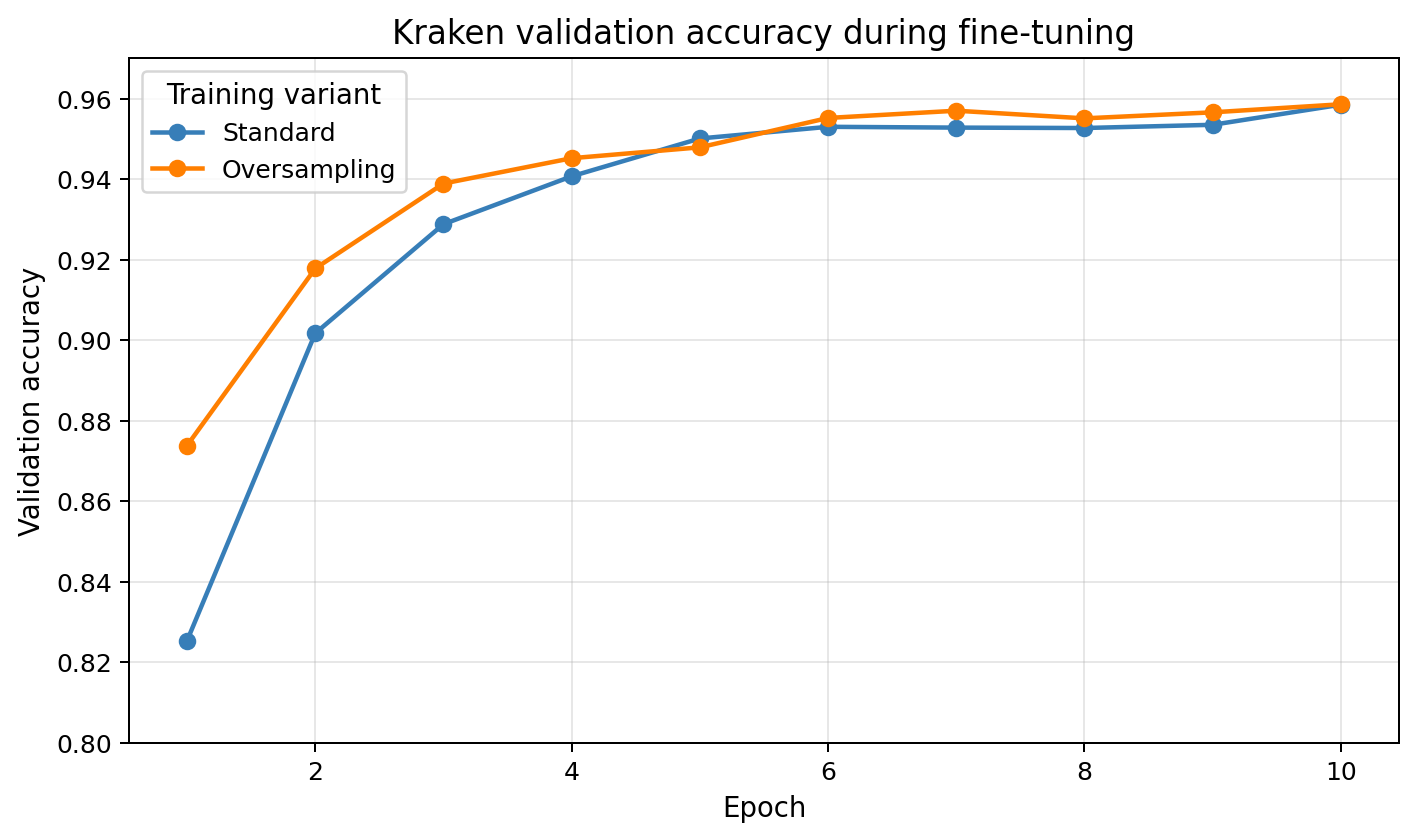

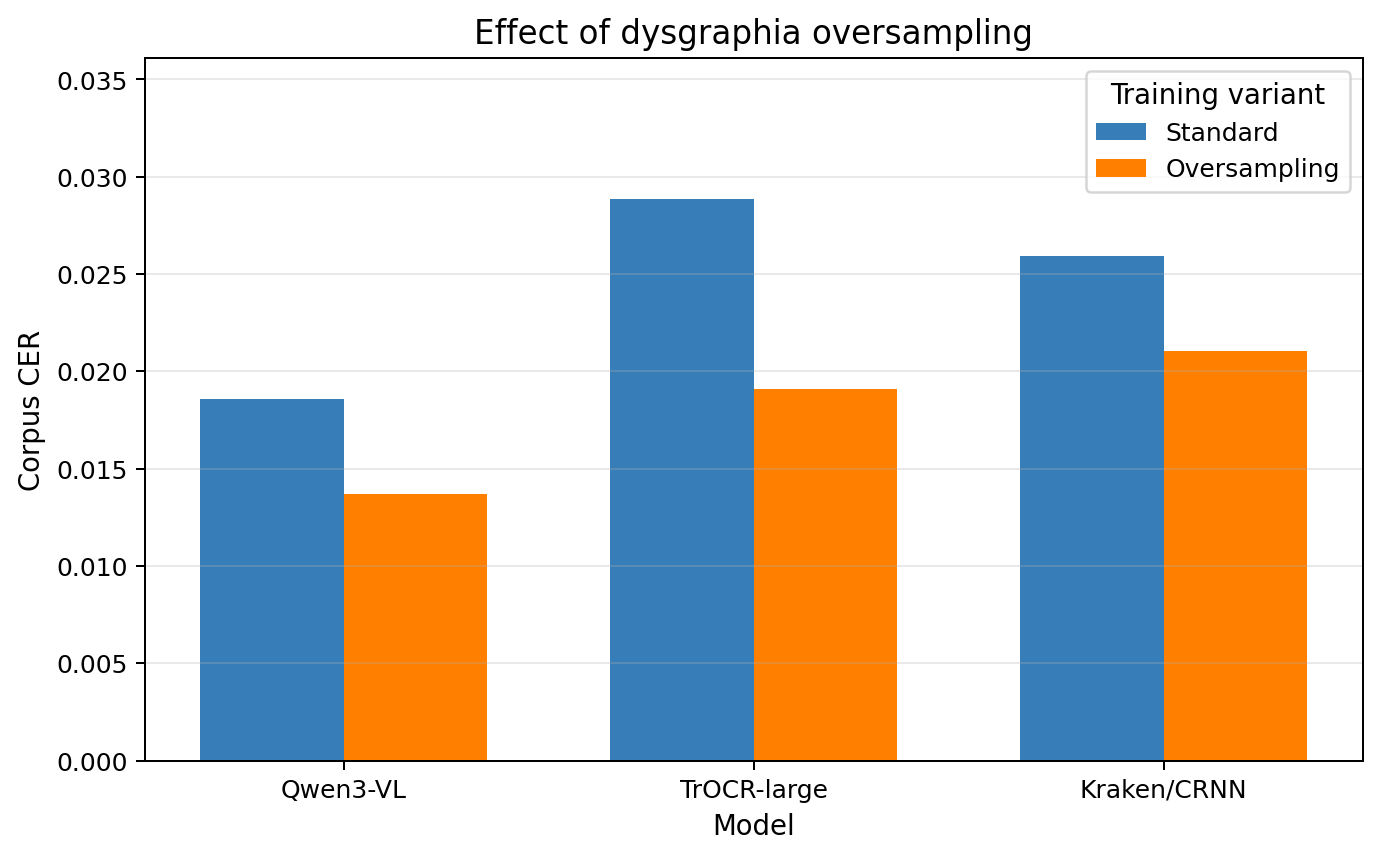

In [7]:
display(Image(filename=str(FIGURES / 'kraken_training_val_accuracy.png')))
display(Image(filename=str(FIGURES / 'dysgraphia_oversampling_cer.png')))


## Resource usage


In [8]:
pd.read_csv(TABLES / 'resource_summary_selected.csv').query("model == 'Kraken/CRNN'")


model,variant,inference_seconds_mean,cuda_peak_allocated_mb_max,cuda_peak_reserved_mb_max,rss_after_mb_max
Kraken/CRNN,FT oversampling,0.1263,NaN,NaN,1204.6000


## Character-level error analysis


In [9]:
pd.read_csv(TABLES / 'top_character_substitutions_best_models.csv').query("model == 'Kraken/CRNN'").head(12)


model,operation,reference_char,predicted_char,count
Kraken/CRNN,substitution,l,ł,4.0000
Kraken/CRNN,substitution,o,a,3.0000
Kraken/CRNN,substitution,c,s,2.0000
Kraken/CRNN,substitution,e,o,2.0000
Kraken/CRNN,substitution,,i,2.0000
Kraken/CRNN,substitution,ą,a,2.0000
Kraken/CRNN,substitution,i,e,2.0000
Kraken/CRNN,substitution,z,ż,2.0000
Kraken/CRNN,substitution,e,c,2.0000
Kraken/CRNN,substitution,L,l,1.0000


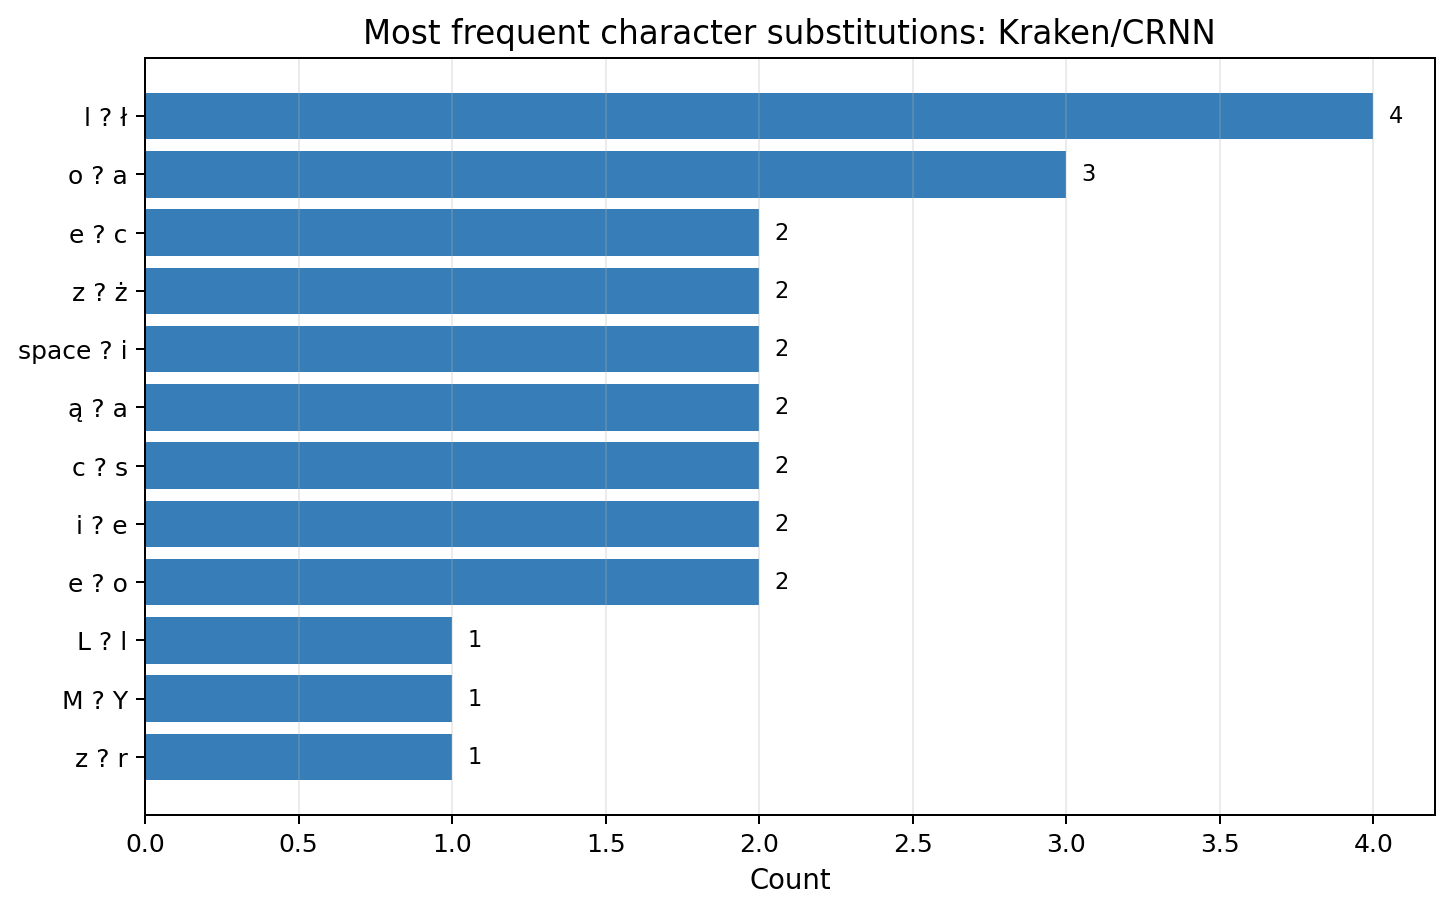

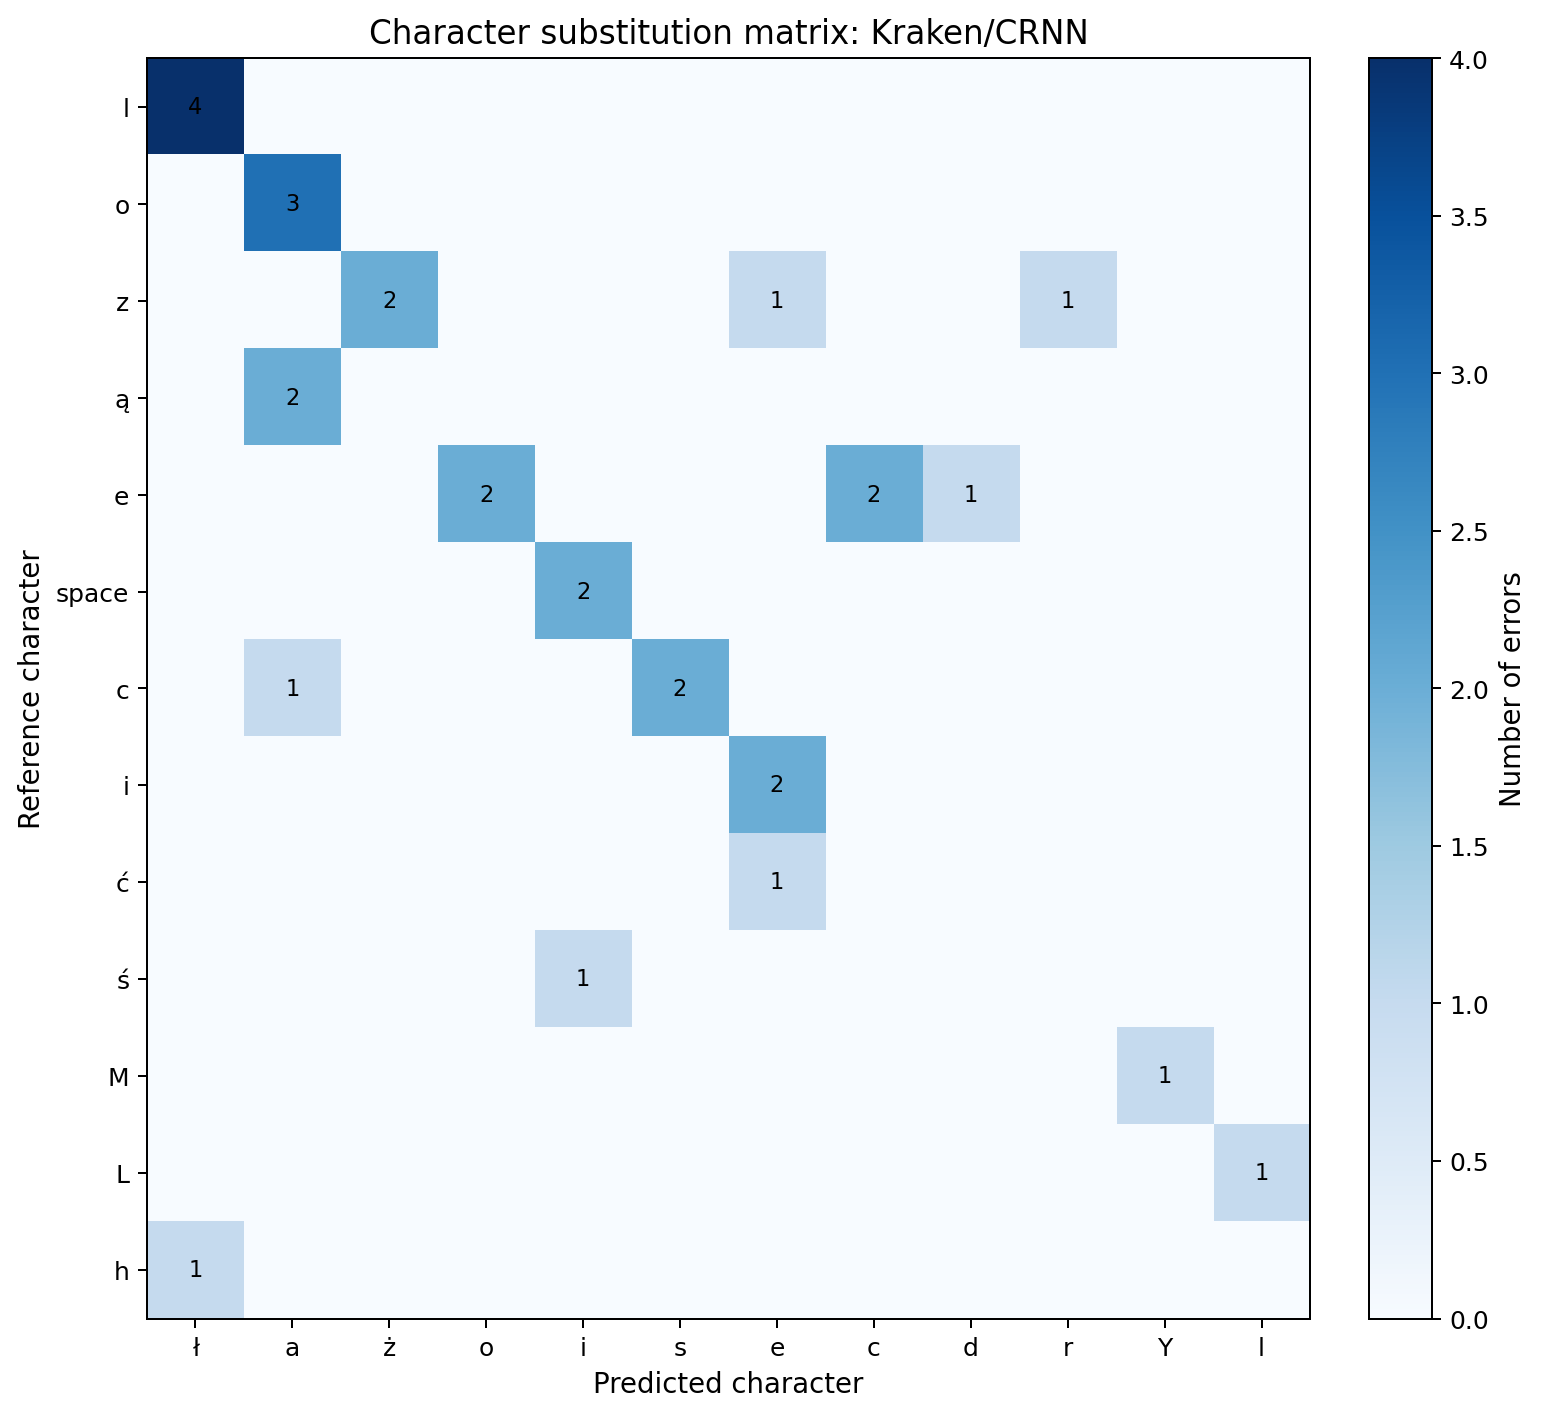

In [10]:
display(Image(filename=str(FIGURES / 'top_character_substitutions_kraken_crnn.png')))
display(Image(filename=str(FIGURES / 'character_substitution_heatmap_kraken_crnn.png')))
